In [1]:
!pip install pyts
!pip install dtaidistance

# Домашнее задание

1. Генерим 21 сигналов (временных рядов), 3 класса по 7 образцов в каждом. 
Постарайтесь сделать их как можно более похожими, и в тоже время различными. 

1. Рассчитываем расстояние между ними по формуле Евклида и с помощью DTW

1. Описываем кратко полученные значения

1. Формируем из нагенеренных временных рядов набор данных для обучения

1. Разбиваем набор на train и test

1. Обучаем  классификаторы KNN с DTW, KNN со стандартной метрикой расстояния, TimeSeriesForest

1. Описываем кратко полученные результаты

In [2]:
import matplotlib.pyplot as plt
import numpy as np

Генерация сигнала

1 тип - гармонический (косинус)

2 тип - модифицированный синус

3 тип - пульс - сигнал

Для выполнения дз надо нагенерить 21 сигнал, по 7 сигналов каждого типа

In [3]:
def pulse(t):
    """Пульс сигнал"""
    return 1 * (abs(t) < 0.5)

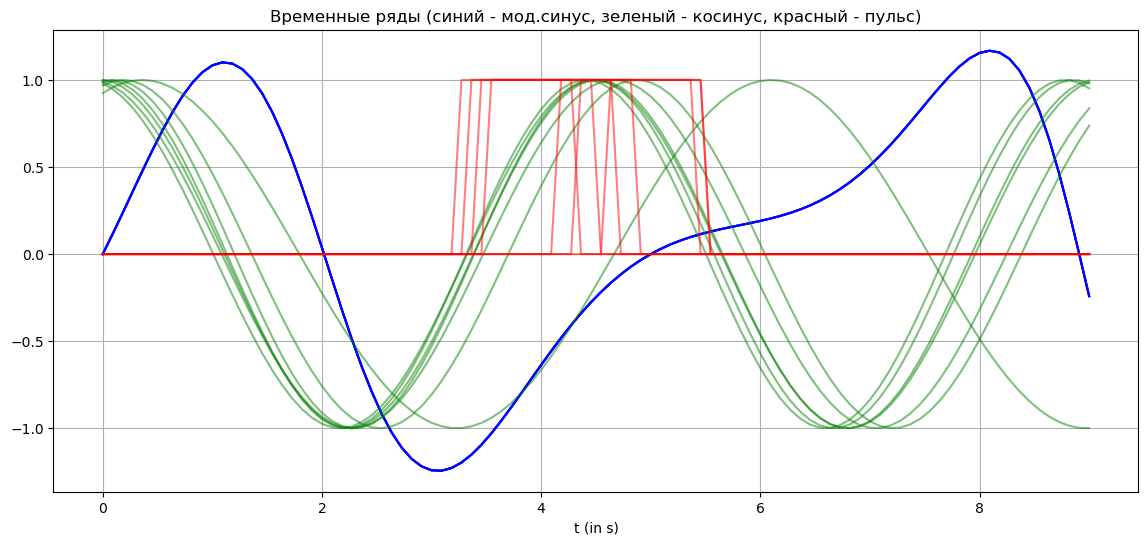

In [4]:
# индекс и отсчет времени в секундах
time_index = np.linspace(0, 9, 100)

tseries_list = {'Time': time_index}
d = np.random.random(size=10)


N = 7 #количество образцов в каждом типе сигналов


# гармонические колебания
f0 = 0.2
for i in range(N):
    freq = f0 + np.random.uniform(-0.03, 0.03)
    phase = np.random.uniform(-0.5, 0.5)
    tseries_list[f"Tc{i}"] = np.cos(2 * np.pi * freq * time_index + phase)

# модифицированный синус 
for i in range(N):
    amp_mod = 1 + 0.3 * np.sin(2 * np.pi * 0.05 * time_index)
    freq_mod = 0.2 + 0.05 * np.sin(2 * np.pi * 0.1 * time_index)
    tseries_list[f"Ts{i}"] = amp_mod * np.sin(2 * np.pi * freq_mod * time_index)


# пульс сигнал
def pulse(t, center=4.5, width=1.0):
    return 1.0 * (np.abs(t - center) < width/2)

for i in range(N):
    center = 4.5 + np.random.uniform(-0.8, 0.8)
    width = 1.2 + np.random.uniform(-0.3, 0.3)
    tseries_list[f"Tp{i}"] = pulse(time_index, center, width)


# отрисовка всех сигналов
plt.figure(figsize=(14, 6))
for i in range(N):
    plt.plot(time_index, tseries_list[f"Ts{i}"], '-b', alpha=0.5)
for i in range(N):
    plt.plot(time_index, tseries_list[f"Tc{i}"], '-g', alpha=0.5)
for i in range(N):
    plt.plot(time_index, tseries_list[f"Tp{i}"], '-r', alpha=0.5)
plt.title('Временные ряды (синий - мод.синус, зеленый - косинус, красный - пульс)')
plt.xlabel('t (in s)')
plt.grid()
plt.show()

# Понимание Динамическое искажение (деформация) времени (Dynamic time warping, DTW)

DTW - это метод, который вычисляет оптимальное соответствие между двумя заданными последовательностями (например, временными рядами) с определенными ограничениями и правилами:

1. Каждый индекс из первой последовательности должен быть сопоставлен с одним или несколькими индексами из другой последовательности и наоборот

1. Первый индекс из первой последовательности должен совпадать с первым индексом из другой последовательности (но это не обязательно должно быть его единственным совпадением)

1. Последний индекс из первой последовательности должен совпадать с последним индексом из другой последовательности (но это не обязательно должно быть его единственным совпадением)

1. Отображение индексов из первой последовательности на индексы из другой последовательности должно монотонно возрастать, и наоборот, т. е. если j>i являются индексами из первой последовательности, то в другой последовательности не должно быть двух индексов l> k, так что индекс i совпадает с индексом l, а индекс j - с индексом k, и наоборот.

Рассмотрим два временных ряда $x$ и $x^{\prime}$ соответствующей длины n и m. Предполагается, что все элементы этих рядов лежат в одном и том же  p - одномерном пространство и точные временные метки, в которые происходят наблюдения, не принимаются во внимание, важен только их порядок.

Более формально задача оптимизации записывается в виде:

$
DTW_q({x}, {x}^\prime) =
    \min_{\pi \in \mathcal{A}({x}, {x}^\prime)}
        \left( \sum_{(i, j) \in \pi} d(x_i, x^\prime_j)^q \right)^{\frac{1}{q}}
$

 
Здесь путь выравнивания $\pi$  длины K  представляет собой последовательность K  пары индексов $((i_0,j_0),..,(i_{K-1},j_{K-1}))$
 и  $A(x,x^{\prime})$
 представляет собой набор всех допустимых путей. Чтобы считаться допустимым, путь должен удовлетворять следующим условиям:

Начало (соответственно, конец) временных рядов сопоставляются друг с другом:

$
\pi_0 = (0, 0)
$

$
\pi_{K-1} = (n - 1, m - 1)
$

Последовательность монотонно увеличивается в обоих $i$ и $j$  и все индексы временных рядов должны отображаться хотя бы один раз, что может быть записано как:

$
i_{k-1} \leq i_k \leq i_{k-1} + 1
$

$
j_{k-1} \leq j_k \leq j_{k-1} + 1
$


Другим способом представления  DTW является использование двоичной матрицы, ненулевые элементы которой соответствуют совпадениям между элементами временного ряда. Это представление связано с представлением последовательности индексов, использованным выше:

$
\begin{equation}
(A_\pi)_{i,j} = \left\{ \begin{array}{rl} 1 & \text{ if } (i, j) \in \pi \\
                                      0 & \text{ otherwise}
                        \end{array} \right. \,\,\,\,\,\,\, .
\end{equation}
$

Тогда  DTW может быть выражено через скалярные произведения следующим образом:

$
DTW_q({x}, {x}^\prime) =
    \min_{\pi \in \mathcal{A}({x}, {x}^\prime)}
        \left\langle A_\pi,  D_q({x}, {x}^\prime) \right\rangle^{\frac{1}{q}}
 $ 

Решение поставленной задачи оптимизации может быть найдено с помощью динамического программирования.
Обозначим:

$
R_{i,j} = DTW_q({x}_{\rightarrow i}, {x}^\prime_{\rightarrow j})^q
$

где ${x}_{\rightarrow i}$ - обозначает наблюдение ряда до отметки i

Тогда получаем реккурентную формулу:

$
\begin{aligned}
R_{i,j} 
    &= \min_{\pi \in \mathcal{A}({x}_{\rightarrow i}, {x}^\prime_{\rightarrow j})}
        \sum_{(k, l) \in \pi} d(x_k, x^\prime_l)^q \\
    &\stackrel{*}{=} d(x_i, x^\prime_j)^q +
        \min_{\pi \in \mathcal{A}({x}_{\rightarrow i}, {x}^\prime_{\rightarrow j})}
            \sum_{(k, l) \in \pi[:-1]} d(x_k, x^\prime_l)^q \\
    &\stackrel{**}{=} d(x_i, x^\prime_j)^q +
        \min ({\color{Blue}R_{i-1, j}}, {\color{Red}R_{i, j-1}}, {\color{ForestGreen}R_{i-1, j-1}})
\end{aligned}
$

\* - потому, что последний элемент на допустимом пути должен соответствовать последним элементам ряда.

** - результат условий смежности допустимых путей.

In [5]:
def distance_matrix(x, y, q) -> np.array:
    """
    Функция расчета матрицы расстояний между точками двух рядов 
    """
    mdist = np.zeros((len(y), len(x)))
    
    for i in range(len(y)):
        for j in range(len(x)):
            mdist[i, j] = abs(x[j] - y[i]) ** q
    
    return mdist

In [6]:
# Посчитаем DTW для двух временных рядов
# Сначала напишем функцию, которая это все вычисляет

def DTW(x, x_s, q=1, isDTW=True):
    '''
        x: первый ряд
        x_s : второй ряд
        q : степень для вычисления базового расстояния
    '''
    N = len(x) 
    
    dist = distance_matrix(x, x_s, q=2)
    
    R = [[0] * (N+1) for i in range(N+1)]
   
    for i in range(1, N): 
        R[i][0] = dist[i-1][0] + R[i-1][0] 
        R[0][i] = dist[0][i-1] + R[0][i-1]
    
    # начинаем расчет по реккурентной формуле
    for i in range(1, N+1): 
        for j in range(1, N+1):
            if isDTW:
                R[i][j] = dist[i-1][j-1] + min(R[i-1][j], R[i][j-1], R[i-1][j-1])
            else:
                R[i][j] = dist[i-1][j-1] + R[i-1][j-1]

    # ищем минимальный путь. Начинаем от нижнего правого угла.
    pth = []   # лист с кортежами индексов пути
    i = N
    j = N
    while i > 0 and j > 0:
        pth.append((i, j))
        
        if i == 0:
            j -= 1
        elif j == 0:
            i -= 1
        else:
            if R[i][j-1] <= R[i-1][j-1] and R[i][j-1] <= R[i-1][j]:
                j -= 1
            elif R[i-1][j] <= R[i-1][j-1] and R[i-1][j] <= R[i][j-1]:
                i -= 1
            else:
                i -= 1
                j -= 1
    
    pth.append((0, 0))
    pth.reverse()

    # Считаем расстояние между двумя рядами
    s = 0
    for l in pth:
        s += R[l[0]][l[1]]
    s = s / len(pth) 

    return s, pth, R

In [7]:
# Посчитаем DTW для двух временных рядов

#для простоты выделяем ряды, которые будем сравнивать
x = np.abs(tseries_list.get("Ts1", np.zeros(100))) # Если tseries_list не заполнен
x_s = np.abs(tseries_list.get("Ts6", np.zeros(100)))
x_p = np.abs(tseries_list.get("Tp2", np.zeros(100)))

s1 = DTW(x, x_s, q=2)
s2 = DTW(x, x_p, q=2)

print(f"DTW\nTs1 и Ts6 = {s1[0]}     Ts1 и Tp2 = {s2[0]}")

s11 = DTW(x, x_s, q=2, isDTW=False)
s21 = DTW(x, x_p, q=2, isDTW=False)

print(f"Euclidean\nTs1 и Ts6 = {s11[0]}     Ts1 и Tp2 = {s21[0]}")

DTW
Ts1 и Ts6 = 0.0     Ts1 и Tp2 = 6.5268401666927085
Euclidean
Ts1 и Ts6 = 0.0     Ts1 и Tp2 = 18.492384090973996


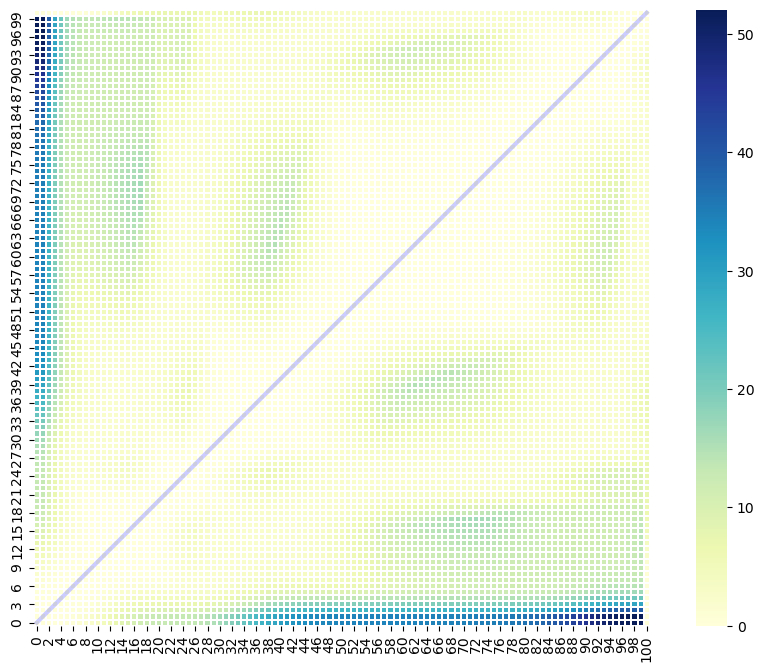

In [8]:
import seaborn as sbn
# Отрисуем матрицы весов расстояний Ts1 и Ts3 

cost_matrix = s1[2]
warp_path = s1[1]

fig, ax = plt.subplots(figsize=(12, 8))
ax = sbn.heatmap(cost_matrix, square=True, linewidths=0.1, cmap="YlGnBu", ax=ax)
ax.invert_yaxis()


path_x = [p[0] for p in warp_path]
path_y = [p[1] for p in warp_path]

# Align the path from the center of each cell
path_xx = [x+0.5 for x in path_x]
path_yy = [y+0.5 for y in path_y]

ax.plot(path_xx, path_yy, color='blue', linewidth=3, alpha=0.2)

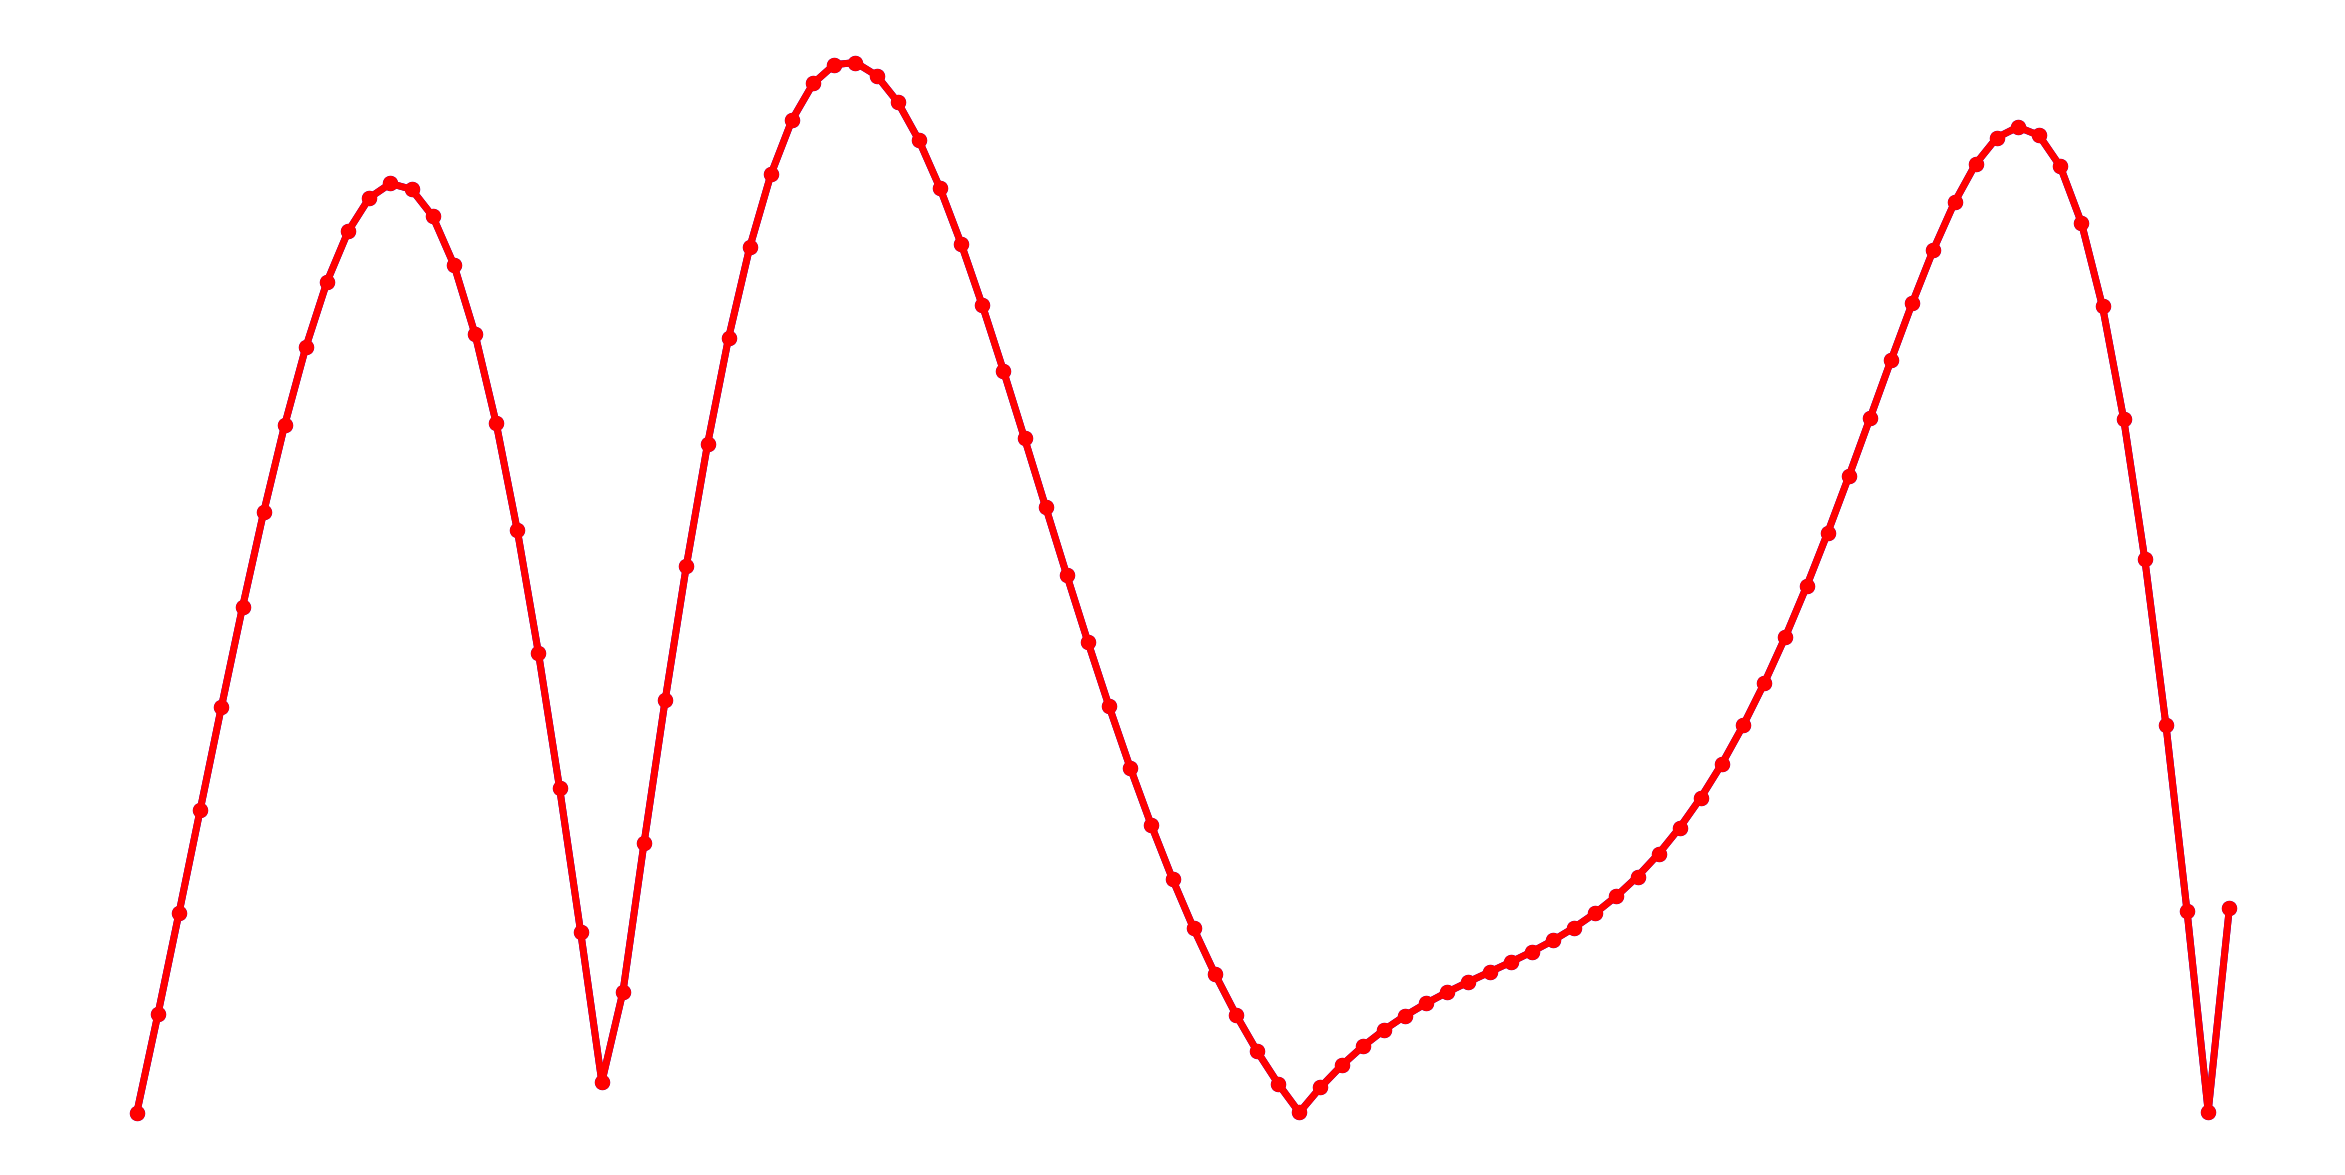

In [9]:
fig, ax = plt.subplots(figsize=(30, 15))


warp_path = s1[1]
x1 = x
x2 = x_s

# Remove the border and axes ticks
fig.patch.set_visible(True)
ax.axis('off')

for [map_x, map_y] in warp_path:   
    ax.set_facecolor('white')
    ax.plot([map_x-1, map_y-1], [x1[map_x-1], x2[map_y-1]], '-k')

ax.plot(x1, color='blue', marker='o', markersize=10, linewidth=5)
ax.plot(x2, color='red', marker='o', markersize=10, linewidth=5)
ax.tick_params(axis="both", which="major", labelsize=18)

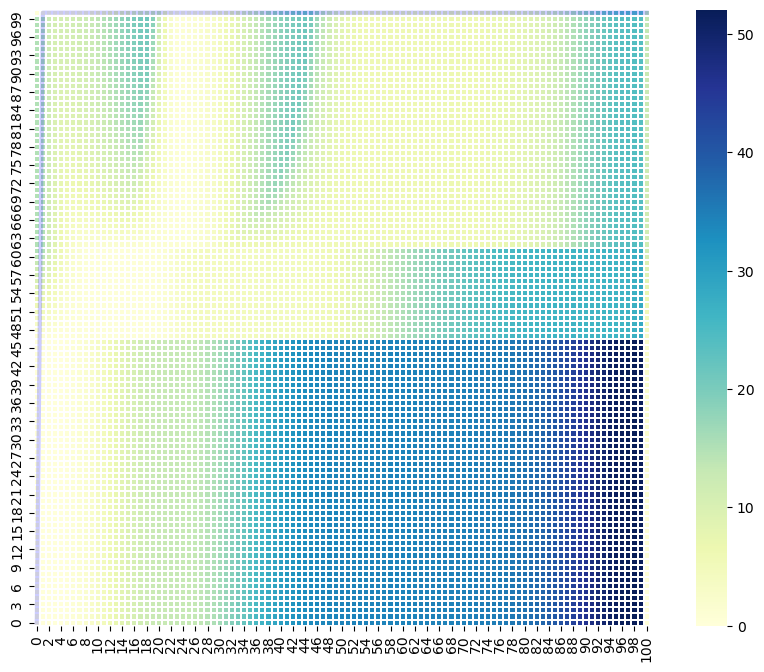

In [10]:
# Отрисуем матрицы весов расстояний Ts1 и Tp1

cost_matrix = s2[2]
warp_path = s2[1]

fig, ax = plt.subplots(figsize=(12, 8))
ax = sbn.heatmap(cost_matrix, square=True, linewidths=0.1, cmap="YlGnBu", ax=ax)
ax.invert_yaxis()


path_x = [p[0] for p in warp_path]
path_y = [p[1] for p in warp_path]

# Align the path from the center of each cell
path_xx = [x+0.5 for x in path_x]
path_yy = [y+0.5 for y in path_y]

ax.plot(path_xx, path_yy, color='blue', linewidth=3, alpha=0.2)

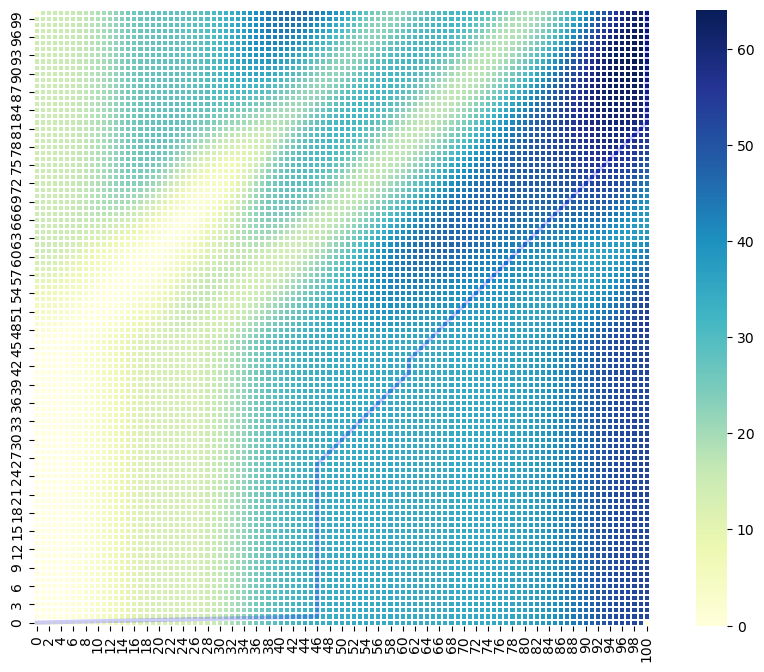

In [11]:
# Отрисуем матрицы весов расстояний Ts1 и Tp1 без DTW

cost_matrix = s21[2]
warp_path = s21[1]

fig, ax = plt.subplots(figsize=(12, 8))
ax = sbn.heatmap(cost_matrix, square=True, linewidths=0.1, cmap="YlGnBu", ax=ax)
ax.invert_yaxis()


path_x = [p[0] for p in warp_path]
path_y = [p[1] for p in warp_path]

# Align the path from the center of each cell
path_xx = [x+0.5 for x in path_x]
path_yy = [y+0.5 for y in path_y]

ax.plot(path_xx, path_yy, color='blue', linewidth=3, alpha=0.2)

А теперь попробуем вычислить тоже самое, но с помощью встроенных функций Python

In [12]:
from dtaidistance import dtw

x = np.abs(tseries_list.get("Ts1", np.zeros(100)))
x_s = np.abs(tseries_list.get("Ts6", np.zeros(100)))

distance = dtw.distance(x, x_s)
paths = dtw.warping_paths(x, x_s)

print(f"Расстояние DTW: {distance}")
print(f"Пути: {paths}")

Расстояние DTW: 0.0
Пути: (0.0, array([[0.        ,        inf,        inf, ...,        inf,        inf,
               inf],
       [       inf, 0.        , 0.1166015 , ..., 7.21590191, 7.21590199,
        7.21994854],
       [       inf, 0.1166015 , 0.        , ..., 6.27418874, 6.27525165,
        6.27649831],
       ...,
       [       inf, 7.21590191, 6.27418874, ..., 0.        , 0.23734633,
        0.23736843],
       [       inf, 7.21590199, 6.27525165, ..., 0.23734633, 0.        ,
        0.24058539],
       [       inf, 7.21994854, 6.27649831, ..., 0.23736843, 0.24058539,
        0.        ]]))


Расстояние DTW: 0.0


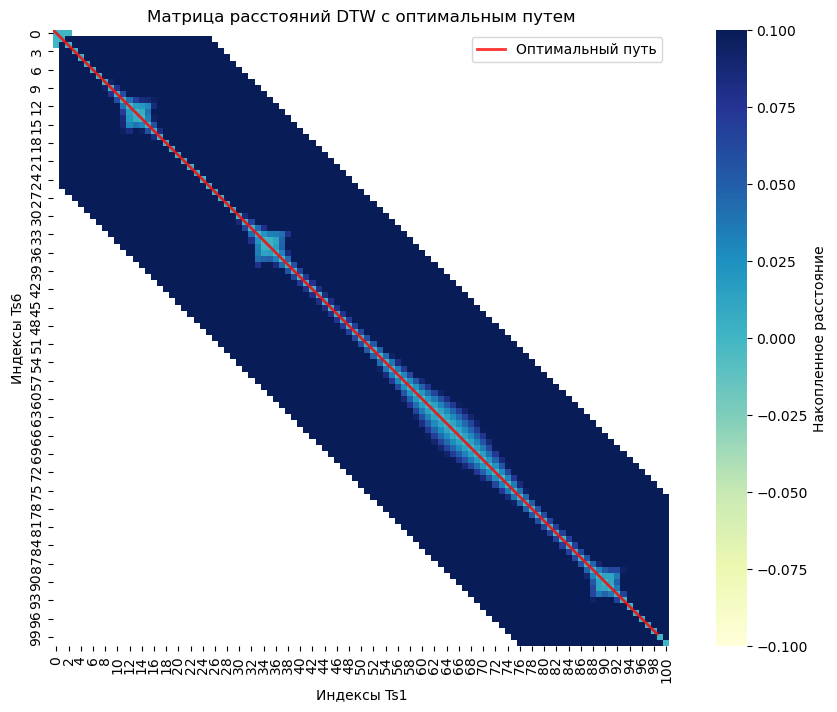

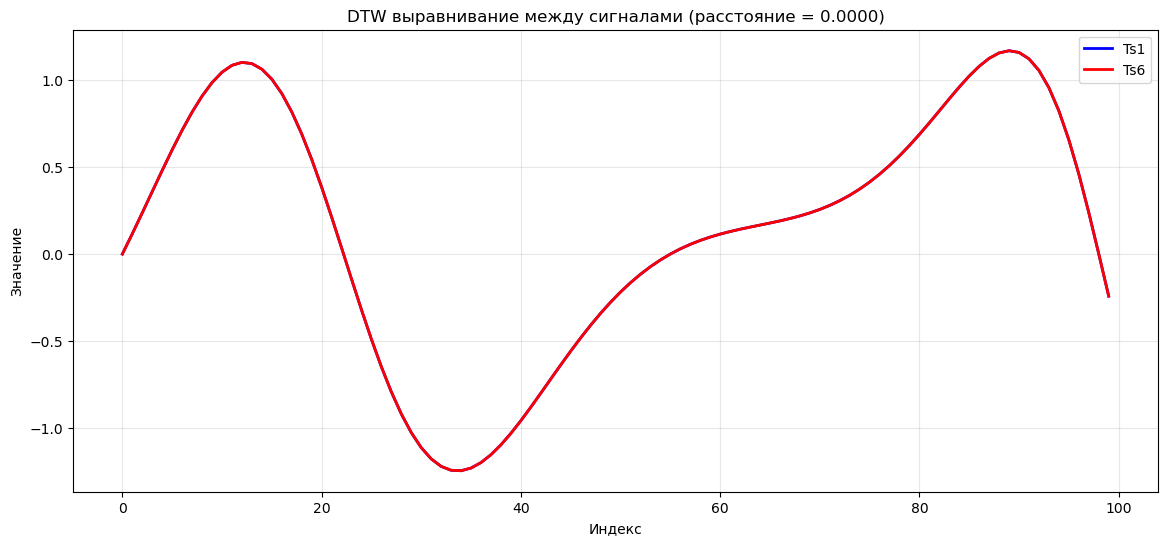

In [15]:
from dtaidistance import dtw
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

x = tseries_list.get("Ts1", np.zeros(100))
x_s = tseries_list.get("Ts6", np.zeros(100))

s1 = x.tolist()
s2 = x_s.tolist()

d, paths = dtw.warping_paths(s1, s2, window=25, psi=2)
best_path = dtw.best_path(paths)

print(f"Расстояние DTW: {d}")

plt.figure(figsize=(12, 8))
sns.heatmap(paths, cmap='YlGnBu', square=True, cbar_kws={'label': 'Накопленное расстояние'})
plt.title('Матрица расстояний DTW с оптимальным путем')
plt.xlabel('Индексы Ts1')
plt.ylabel('Индексы Ts6')

path_x = [p[0] for p in best_path]
path_y = [p[1] for p in best_path]
plt.plot(path_y, path_x, 'r-', linewidth=2, alpha=0.8, label='Оптимальный путь')
plt.legend()
plt.show()

plt.figure(figsize=(14, 6))
for (i, j) in best_path:
    plt.plot([i, j], [s1[i], s2[j]], 'k-', alpha=0.1, linewidth=0.5)
plt.plot(s1, 'b-', label='Ts1', linewidth=2)
plt.plot(s2, 'r-', label='Ts6', linewidth=2)
plt.legend()
plt.title(f'DTW выравнивание между сигналами (расстояние = {d:.4f})')
plt.xlabel('Индекс')
plt.ylabel('Значение')
plt.grid(alpha=0.3)
plt.show()

In [16]:
x = np.abs(tseries_list["Ts1"])
x_p = np.abs(tseries_list["Tp2"])


distance, paths = dtw.warping_paths(x, x_p)
print(distance)
print(paths)

4.894577175603471
[[0.                inf        inf ...        inf        inf        inf]
 [       inf 0.         0.         ... 3.87298335 3.87298335 3.87298335]
 [       inf 0.1166015  0.1166015  ... 3.49412969 3.49607468 3.4980186 ]
 ...
 [       inf 7.21590191 7.21590191 ... 4.88860605 4.88860605 4.88860605]
 [       inf 7.21590199 7.21590199 ... 4.88860618 4.88860618 4.88860618]
 [       inf 7.21994854 7.21994854 ... 4.89457718 4.89457718 4.89457718]]


Расстояние DTW: 7.1124064834922605


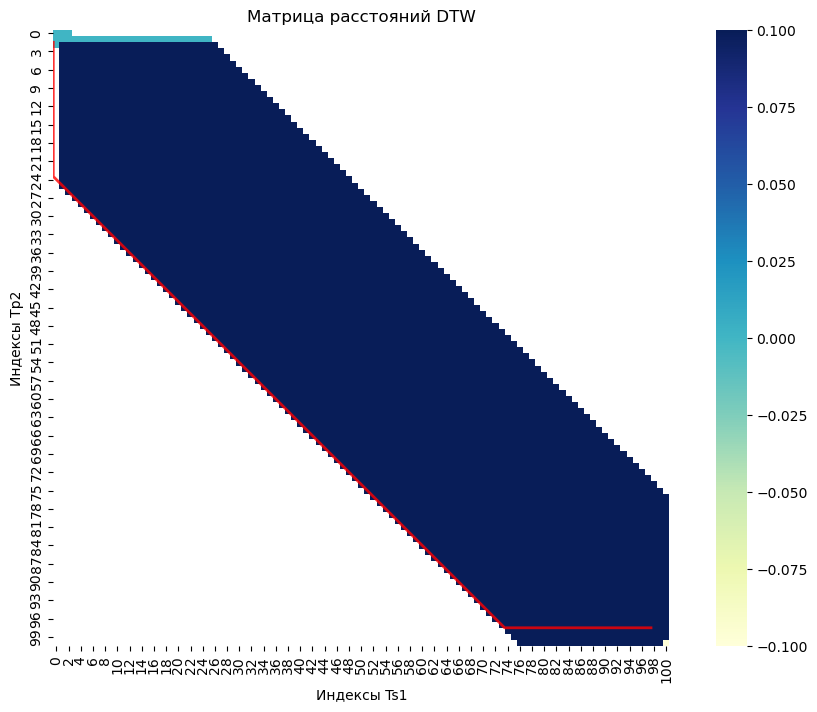

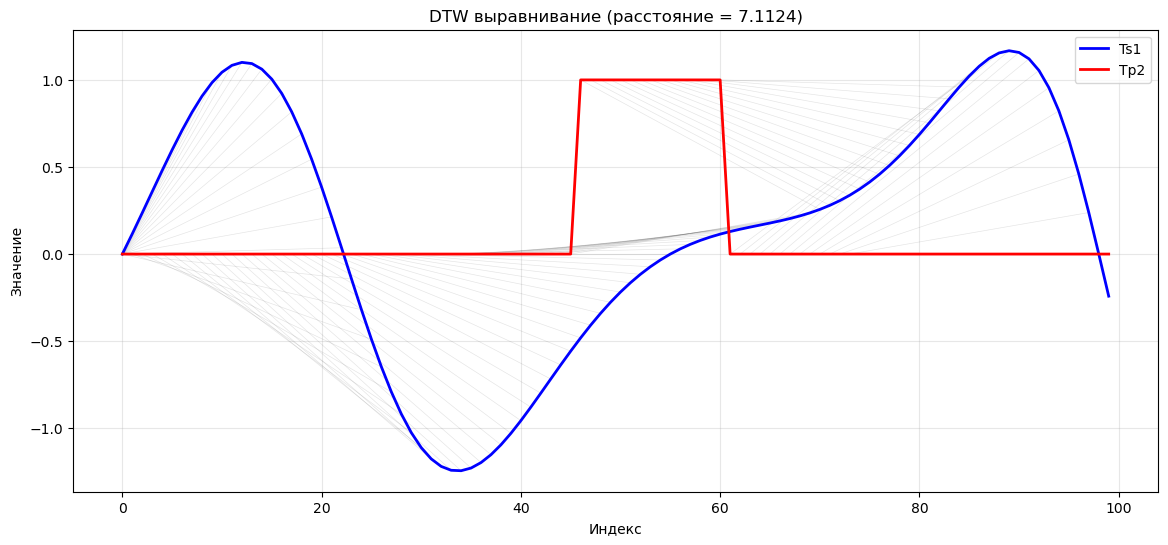

In [18]:
from dtaidistance import dtw
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

x = tseries_list.get("Ts1", np.zeros(100))
x_p = tseries_list.get("Tp2", np.zeros(100))

s1 = x.tolist()
s2 = x_p.tolist()

d, paths = dtw.warping_paths(s1, s2, window=25, psi=2)
best_path = dtw.best_path(paths)

print(f"Расстояние DTW: {d}")

plt.figure(figsize=(12, 8))
sns.heatmap(paths, cmap='YlGnBu', square=True)
plt.title('Матрица расстояний DTW')
plt.xlabel('Индексы Ts1')
plt.ylabel('Индексы Tp2')

path_x = [p[0] for p in best_path]
path_y = [p[1] for p in best_path]
plt.plot(path_y, path_x, 'r-', linewidth=2, alpha=0.8)
plt.show()

plt.figure(figsize=(14, 6))
for (i, j) in best_path:
    plt.plot([i, j], [s1[i], s2[j]], 'k-', alpha=0.1, linewidth=0.5)
plt.plot(s1, 'b-', label='Ts1', linewidth=2)
plt.plot(s2, 'r-', label='Tp2', linewidth=2)
plt.legend()
plt.title(f'DTW выравнивание (расстояние = {d:.4f})')
plt.xlabel('Индекс')
plt.ylabel('Значение')
plt.grid(alpha=0.3)
plt.show()

In [21]:
# переделываем датасет так, чтобы с ним можно было бы работать

x = []  # значения
Y = []  # целевая переменная

for v in tseries_list:
    if v != 'Time':
        x.append(tseries_list[v])
        c = v[:-1]
        if c == "Ts":
            Y.append(0)
        elif c == "Tc":
            Y.append(1)
        else: 
            Y.append(2)

X = np.array(x)
Y = np.array(Y)

print(f"X shape: {X.shape}")
print(f"Y shape: {Y.shape}")

arr = np.arange(len(Y))
np.random.shuffle(arr)

X_shuffled = X[arr]
Y_shuffled = Y[arr]

X_train = X_shuffled[:-5]
X_test = X_shuffled[-5:]
y_train = Y_shuffled[:-5]
y_test = Y_shuffled[-5:]

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train: {y_train}")
print(f"y_test: {y_test}")

X shape: (21, 100)
Y shape: (21,)
X_train shape: (16, 100)
X_test shape: (5, 100)
y_train: [1 0 0 1 2 0 2 1 2 0 1 1 0 1 2 2]
y_test: [2 2 1 0 0]


In [22]:
from pyts.classification import KNeighborsClassifier

clf = KNeighborsClassifier(metric='dtw')
clf.fit(X_train, y_train)

print(f"Accuracy {clf.score(X_test, y_test)}")
print(f"Вектор вероятности принадлежности к классам {clf.predict_proba(X_test[2].reshape(1, -1))}")
print(f"Истинный класс для предсказаний {y_test[2]}")

Accuracy 1.0
Вектор вероятности принадлежности к классам [[0. 1. 0.]]
Истинный класс для предсказаний 1


In [23]:
import numpy as np 
from pyts.classification import TimeSeriesForest
import matplotlib.pyplot as plt

clf = TimeSeriesForest(random_state=43)
clf.fit(X_train, y_train)

print(f"Accuracy {clf.score(X_test, y_test)}")
print(f"Вектор вероятности принадлежности к классам {clf.predict_proba(X_test[2].reshape(1, -1))}")
print(f"Истинный класс для предсказаний {y_test[2]}")

Accuracy 1.0
Вектор вероятности принадлежности к классам [[0.014 0.958 0.028]]
Истинный класс для предсказаний 1


In [24]:
# TODO: Обучите модель KNN со стандартной (евклидовой) метрикой расстояния
# В домашнем задании требовалось сделать 3 модели на выбор.

from pyts.classification import KNeighborsClassifier

clf_eucl = KNeighborsClassifier(metric='euclidean')
clf_eucl.fit(X_train, y_train)

print(f"Accuracy {clf_eucl.score(X_test, y_test)}")
print(f"Вектор вероятности принадлежности к классам {clf_eucl.predict_proba(X_test[2].reshape(1, -1))}")
print(f"Истинный класс для предсказаний {y_test[2]}")

Accuracy 1.0
Вектор вероятности принадлежности к классам [[0. 1. 0.]]
Истинный класс для предсказаний 1
